In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [30]:
#load data
data=pd.read_csv("/content/diabetes.csv")

In [31]:
#proprocess zero rows and calculate median to replace 0 with median(better than remove)
cols_with_zeros=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data[cols_with_zeros]=data[cols_with_zeros].replace(0, np.nan)
data.fillna(data.median(),inplace=True)

In [32]:
#print data to check
print(data)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6    148.0           72.0           35.0    125.0  33.6   
1              1     85.0           66.0           29.0    125.0  26.6   
2              8    183.0           64.0           29.0    125.0  23.3   
3              1     89.0           66.0           23.0     94.0  28.1   
4              0    137.0           40.0           35.0    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10    101.0           76.0           48.0    180.0  32.9   
764            2    122.0           70.0           27.0    125.0  36.8   
765            5    121.0           72.0           23.0    112.0  26.2   
766            1    126.0           60.0           29.0    125.0  30.1   
767            1     93.0           70.0           31.0    125.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [33]:
#split to train and test
features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
x=data[features]
y=data['Outcome']
x_temp,x_test,y_temp,y_test=train_test_split(x,y,test_size=0.2,random_state=42)#20% 80% better for medical
x_train,x_val,y_train,y_val=train_test_split(x_temp,y_temp,test_size=0.25,random_state=42)

In [34]:
#scale and transform to tensor
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_val=scaler.transform(x_val)
x_test=scaler.transform(x_test)

x_train_tensor=torch.FloatTensor(x_train)
x_val_tensor=torch.FloatTensor(x_val)
x_test_tensor=torch.FloatTensor(x_test)
y_train_tensor=torch.FloatTensor(y_train.values).view(-1,1)
y_val_tensor=torch.FloatTensor(y_val.values).view(-1,1)
y_test_tensor=torch.FloatTensor(y_test.values).view(-1,1)

In [35]:
#model
model=nn.Sequential(
    nn.Linear(8,32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32,16),
    nn.BatchNorm1d(16),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(16,1),
    nn.Sigmoid()
)

In [36]:
#optimizer and loss function and schedular
optimizer=optim.Adam(model.parameters(),lr=0.0025)
lossfn = nn.BCELoss()
scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=30,gamma=0.5)

Epoch 0 | Training Loss: 0.7703 | Validation Loss: 0.6935
Epoch 1 | Training Loss: 0.7536 | Validation Loss: 0.6884
Epoch 2 | Training Loss: 0.7324 | Validation Loss: 0.6827
Epoch 3 | Training Loss: 0.7059 | Validation Loss: 0.6769
Epoch 4 | Training Loss: 0.6934 | Validation Loss: 0.6707
Epoch 5 | Training Loss: 0.6827 | Validation Loss: 0.6642
Epoch 6 | Training Loss: 0.6603 | Validation Loss: 0.6574
Epoch 7 | Training Loss: 0.6478 | Validation Loss: 0.65
Epoch 8 | Training Loss: 0.6465 | Validation Loss: 0.6422
Epoch 9 | Training Loss: 0.629 | Validation Loss: 0.6341
Epoch 10 | Training Loss: 0.613 | Validation Loss: 0.6258
Epoch 11 | Training Loss: 0.6113 | Validation Loss: 0.6174
Epoch 12 | Training Loss: 0.6141 | Validation Loss: 0.6094
Epoch 13 | Training Loss: 0.5972 | Validation Loss: 0.6015
Epoch 14 | Training Loss: 0.5937 | Validation Loss: 0.5937
Epoch 15 | Training Loss: 0.5763 | Validation Loss: 0.5863
Epoch 16 | Training Loss: 0.5836 | Validation Loss: 0.5792
Epoch 17 | 

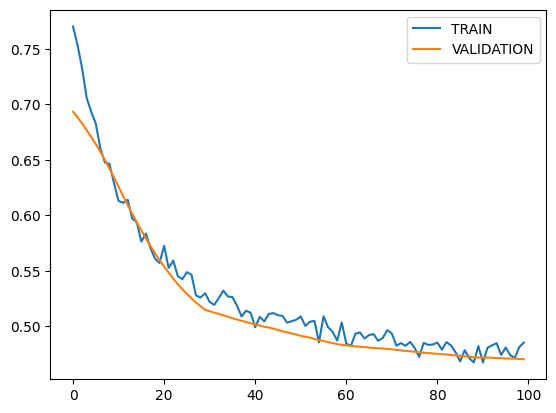

In [37]:
train_loss=[]
val_losses=[]
#early stop
best_val_loss=float('inf')
wait=15
ctr=0

for e in range(100):
  #train
  model.train()
  out=model(x_train_tensor)
  loss=lossfn(out,y_train_tensor)
  #back prop
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  #validation
  model.eval()
  with torch.no_grad():
    val_out=model(x_val_tensor)
    val_loss_value=lossfn(val_out,y_val_tensor)
  train_loss.append(loss.item())
  val_losses.append(val_loss_value.item())
  print(f"Epoch {e} | Training Loss: {loss.item():.4} | Validation Loss: {val_loss_value.item():.4}")

  #schedular
  scheduler.step()
  #early stop
  if val_loss_value < best_val_loss:
    best_val_loss = val_loss_value
    ctr=0
    best_model=model.state_dict()
  else:
    ctr+=1
  if ctr>=wait:
    print("EARLY STOP!")
    model.load_state_dict(best_model)
    break

#visulization
plt.plot(train_loss,label="TRAIN")
plt.plot(val_losses,label="VALIDATION")
plt.legend()
plt.show()

TEST ACCURACY =  0.7077922224998474


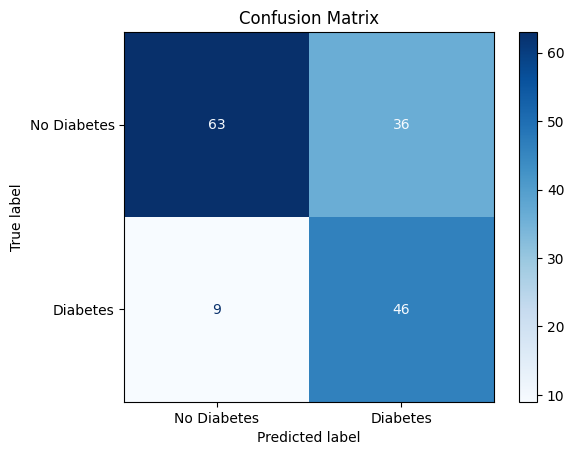

In [38]:
#test model
model.load_state_dict(best_model)
model.eval()
with torch.no_grad():
  pred=model(x_test_tensor)
  pred=(pred>0.35).float()
  accuracy=(pred==y_test_tensor).sum()/y_test_tensor.size(0)
  print("TEST ACCURACY = ",accuracy.item())

  from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_tensor.numpy(), pred.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes','Diabetes'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()